# TinyChirp SincNet-Time TensorFlow

Train a 1D CNN with a SincNet-style learnable frontend directly on raw audio waveforms, export an int8 TFLite model, and write a Rust `audio_sample.rs` file.

This mirrors `building_tensorflow/cnn_time.ipynb` but replaces the first convolutional layer with a custom Sinc-like frontend whose learned filters are later baked into a standard `Conv1D` layer for inference.

In [10]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import tensorflow as tf

from building_tensorflow.utils import ( 
    TARGET_AUDIO_LEN_TIME,
    DATASET_ROOT,
    SAMPLE_RATE,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
    build_representative_batches,
    export_keras_model_to_int8_tflite,
)

configure_tf_runtime()
set_global_seed()

paths = get_paths("sincnet_time_tf")
OUT_TFLITE = paths.out_tflite
BATCH_SIZE = 32

print("Dataset root:", DATASET_ROOT)
print("Model output:", OUT_TFLITE)


Dataset root: /home/nathan/Documents/tiny-chirp-microflow/dataset
Model output: /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_time_tf.tflite


In [12]:
train_ds, val_ds, test_ds, label_names = make_time_datasets()
num_labels = len(label_names)
print("Classes:", label_names)
print(len(train_ds),len(val_ds),len(test_ds))

Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.
Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']
353 44 44


## SincNet-style learnable frontend

We define a simplified SincNet-style learnable filterbank as a custom Keras layer that operates directly on the raw waveform. The layer maintains trainable parameters that are passed through a `sin` nonlinearity to produce filters, which are then applied via a 1D convolution.

In [13]:
import tensorflow as tf
import numpy as np
import math
from building_tensorflow.utils import get_flops_native

class SincnetConv(tf.keras.layers.Layer):
    def __init__(self, num_filters: int, kernel_size: int, stride: int, sample_rate: int = 16000, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.stride = stride
        self.sample_rate = sample_rate
        
        # SincNet requires an odd kernel size for symmetric filters
        self.kernel_size = kernel_size if kernel_size % 2 != 0 else kernel_size + 1

    def build(self, input_shape):
        # 1. Initialize frequencies on the Mel scale
        mel_min = 0.0
        mel_max = self._hz_to_mel(self.sample_rate / 2.0)
        mel_points = np.linspace(mel_min, mel_max, self.num_filters + 1)
        hz_points = self._mel_to_hz(mel_points)
        
        # Normalize frequencies by sample rate (so Nyquist is 0.5)
        f1_init = hz_points[:-1] / self.sample_rate
        band_init = np.diff(hz_points) / self.sample_rate

        # 2. Trainable parameters: low cutoff (f1) and bandwidth (band)
        self.f1 = self.add_weight(
            name='f1',
            shape=(self.num_filters,),
            initializer=tf.keras.initializers.Constant(f1_init),
            trainable=True
        )
        self.band = self.add_weight(
            name='band',
            shape=(self.num_filters,),
            initializer=tf.keras.initializers.Constant(band_init),
            trainable=True
        )

        # 3. Static time grid and Hamming window
        t = np.linspace(-(self.kernel_size // 2), self.kernel_size // 2, self.kernel_size)
        self.t = tf.constant(t, dtype=tf.float32)
        
        window = 0.54 - 0.46 * np.cos(2 * math.pi * np.arange(self.kernel_size) / (self.kernel_size - 1))
        self.window = tf.constant(window, dtype=tf.float32)

    def get_filters(self) -> tf.Tensor:
        # Abs ensures frequencies stay positive
        f1_safe = tf.math.abs(self.f1)
        f2_safe = f1_safe + tf.math.abs(self.band)
        
        f1_mat = tf.reshape(f1_safe, (1, -1))
        f2_mat = tf.reshape(f2_safe, (1, -1))
        t_mat = tf.reshape(self.t, (-1, 1))
        
        # Equation: [sin(2*pi*f2*t) - sin(2*pi*f1*t)] / (pi * t)
        pi_t = math.pi * t_mat
        
        # Prevent division by zero at t=0 by substituting 1.0 (we overwrite the center later)
        denom = tf.where(t_mat == 0.0, 1.0, pi_t)
        
        filters = (tf.math.sin(2.0 * math.pi * f2_mat * t_mat) - 
                   tf.math.sin(2.0 * math.pi * f1_mat * t_mat)) / denom
                   
        # The limit of the function as t approaches 0 is 2(f2 - f1)
        center_values = 2.0 * (f2_mat - f1_mat)
        
        # Inject the mathematical limit into the center index (t=0)
        mask = tf.cast(t_mat == 0.0, tf.float32)
        filters = filters * (1.0 - mask) + center_values * mask
        
        # Apply Hamming Window
        filters = filters * tf.reshape(self.window, (-1, 1))
        
        # Return standard shape: (kernel_size, in_channels, out_channels)
        return tf.reshape(filters, (self.kernel_size, 1, self.num_filters))

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        return tf.nn.conv1d(inputs, self.get_filters(), stride=self.stride, padding="VALID")

    def export_to_conv1d(self, name="baked_sinc_conv") -> tf.keras.layers.Conv1D:
        """Bakes the dynamic Sinc filters into a static, MicroFlow-ready Conv1D."""
        baked_weights = self.get_filters().numpy()

        conv_layer = tf.keras.layers.Conv1D(
            filters=self.num_filters,
            kernel_size=self.kernel_size,
            strides=self.stride,
            padding="valid",
            use_bias=False,
            name=name
        )

        conv_layer.build(input_shape=(None, None, 1))
        conv_layer.set_weights([baked_weights])
        return conv_layer

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_filters": self.num_filters,
            "kernel_size": self.kernel_size,
            "stride": self.stride,
            "sample_rate": self.sample_rate,
        })
        return config

    # Mel-Scale DSP Helpers
    def _hz_to_mel(self, hz):
        return 2595.0 * np.log10(1.0 + hz / 700.0)
    
    def _mel_to_hz(self, mel):
        return 700.0 * (10.0**(mel / 2595.0) - 1.0)

In [14]:
SINCNET_FILTERS = 48
SINCNET_STRIDE = 16
SINCNET_KERNEL_SIZE = 32

CONV_FILTERS = 16
CONV_FILTER_SIZE = 5
CONV_STRIDE = 1

DENSE_HIDDEN = 64


def build_training_model(num_labels: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))
    
    # Use the real SincNet!
    x = SincnetConv(
        num_filters=SINCNET_FILTERS, 
        kernel_size=SINCNET_KERNEL_SIZE, 
        stride=SINCNET_STRIDE, 
        sample_rate=SAMPLE_RATE,
        name="sincnet_convolution"
    )(inputs)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.AveragePooling1D(pool_size=4, name="envelope_pool")(x)
    
    x = tf.keras.layers.Conv1D(
        filters=CONV_FILTERS, 
        kernel_size=CONV_FILTER_SIZE, 
        strides=CONV_STRIDE, 
        padding="same", 
        name="temporal_conv_1"
    )(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.AveragePooling1D(pool_size=4, name="temporal_pool_1")(x)
    
    x = tf.keras.layers.Conv1D(
        filters=CONV_FILTERS, 
        kernel_size=CONV_FILTER_SIZE, 
        strides=CONV_STRIDE, 
        padding="same", 
        name="temporal_conv_2"
    )(x)
    x = tf.keras.layers.ReLU()(x)
    
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    
    x = tf.keras.layers.Dense(DENSE_HIDDEN, activation="relu", name="dense_hidden")(x)
    outputs = tf.keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)
    
    return tf.keras.Model(inputs, outputs, name="sincnet_training")

training_model = build_training_model(num_labels)
training_model.summary()

flops = get_flops_native(training_model, batch_size=1)
print(f"Total FLOPs: {flops}")

Model: "sincnet_training"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 47872, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sincnet_convolution             │ (None, 2990, 48)       │            96 │
│ (SincnetConv)                   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 2990, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ envelope_pool                   │ (None, 747, 48)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_1 (Conv1D)        │ (None, 747, 16)        │         3,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 747, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pool_1                 │ (None, 186, 16)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_2 (Conv1D)        │ (None, 186, 16)        │         1,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 186, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_logits (Dense)            │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,466 (25.26 KB)

 Trainable params: 6,466 (25.26 KB)

 Non-trainable params: 0 (0.00 B)

Total FLOPs: 15874086


/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_18
Received: inputs=['Tensor(shape=(1, 47872, 1))']
  warnings.warn(msg)
2026-04-15 16:08:01.979528: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-15 16:08:01.980498: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-04-15 16:08:01.980565: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-04-15 16:08:01.981017: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful 

In [15]:
from building_tensorflow.utils import init_wandb, get_callbacks, finish_wandb

training_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

init_wandb("sincnet_complex", config={
    "sincnet_num_filters": SINCNET_FILTERS,
    "sincnet_kernel_size": SINCNET_KERNEL_SIZE,
    "sincnet_stride": SINCNET_STRIDE,
    "conv_filters": CONV_FILTERS,
    "conv_filter_size": CONV_FILTER_SIZE,
    "conv_stride": CONV_STRIDE,
    "dense_hidden": DENSE_HIDDEN,
})

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    validation_steps=44,
    callbacks=get_callbacks(10,5,BATCH_SIZE)
)
finish_wandb()

Epoch 1/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.8284 - loss: 0.3552 - val_accuracy: 0.9283 - val_loss: 0.1971
Epoch 2/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.9085 - loss: 0.2328 - val_accuracy: 0.9275 - val_loss: 0.1936
Epoch 3/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.9215 - loss: 0.2140 - val_accuracy: 0.9384 - val_loss: 0.1760
Epoch 4/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.9293 - loss: 0.1884 - val_accuracy: 0.9420 - val_loss: 0.1627
Epoch 5/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9338 - loss: 0.1742 - val_accuracy: 0.9428 - val_loss: 0.1477
Epoch 6/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.9391 - loss: 0.1578 - val_accuracy: 0.9442 - val_loss: 0.1370
Epoch 7/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.9466 - loss: 0.1417 - val_accuracy: 0.9493 - val_loss: 0.1236
Epoch 8/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.9521 - loss: 0

wandb: WARNING A graphql request initiated by the public wandb API timed out (timeout=19 sec). Create a new API with an integer timeout larger than 19, e.g., `api = wandb.Api(timeout=29)` to increase the graphql timeout.


353/353 ━━━━━━━━━━━━━━━━━━━━ 39s 110ms/step - accuracy: 0.9898 - loss: 0.0300 - val_accuracy: 0.9906 - val_loss: 0.0274
Epoch 49/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.9903 - loss: 0.0280 - val_accuracy: 0.9913 - val_loss: 0.0304
Epoch 50/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.9919 - loss: 0.0283 - val_accuracy: 0.9899 - val_loss: 0.0323
Epoch 51/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.9897 - loss: 0.0301 - val_accuracy: 0.9913 - val_loss: 0.0291
Epoch 52/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.9904 - loss: 0.0272 - val_accuracy: 0.9928 - val_loss: 0.0305
Epoch 53/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9917 - loss: 0.0260 - val_accuracy: 0.9884 - val_loss: 0.0314
Epoch 54/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.9916 - loss: 0.0259 - val_accuracy: 0.9833 - val_loss: 0.0415
Epoch 55/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9906 - loss: 0.027

batch/accuracy,▁▆▆▆▇▇▇▇▇▇▇█████████████████████████████
batch/batch_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇█
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,██▅▅▄▃▃▃▃▃▂▂▂▂▂▁▂▂▂▂▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁▂▃▃▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇█████████████████████
epoch/epoch,▁▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇████
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▇▆▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▁▂▃▃▅▆▆▆▇▆▇▇▇▇▇▇█▇▇█▇▇██████▇███████▇██
epoch/val_loss,██▇▇▆▅▄▄▃▃▃▂▃▂▂▂▃▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▂▁▂▁▁▁▁▁
+6,...


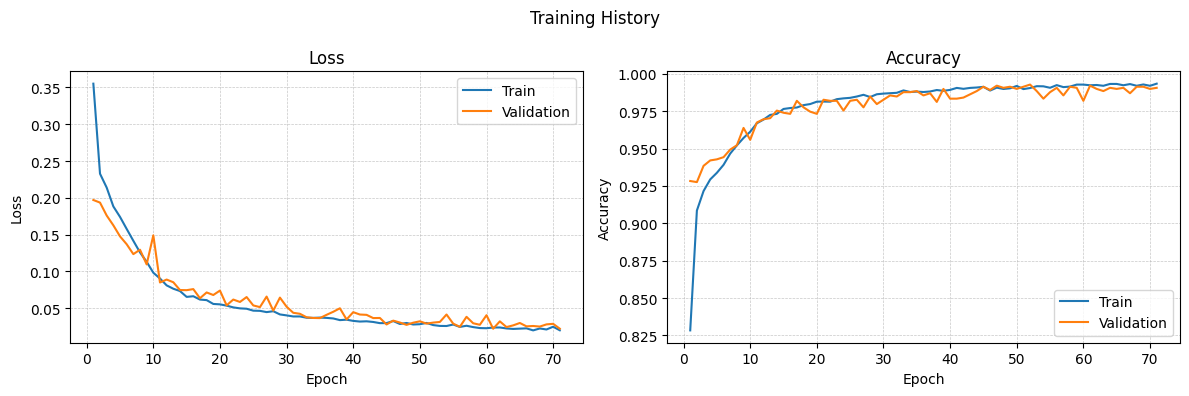

In [16]:
from building_tensorflow.utils import plot_training_history
plot_training_history(history)

353it [00:13, 26.12it/s]2026-04-15 16:41:47.149473: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence

44it [00:01, 26.34it/s]2026-04-15 16:41:49.038563: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
44it [00:01, 26.72it/s]


=== Binary classifier metrics : TEST SET===
Threshold: 0.3364  (best F2 threshold)
Accuracy : 0.9971
Precision: 0.9956
Recall   : 0.9956
F2 score : 0.9956
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9997


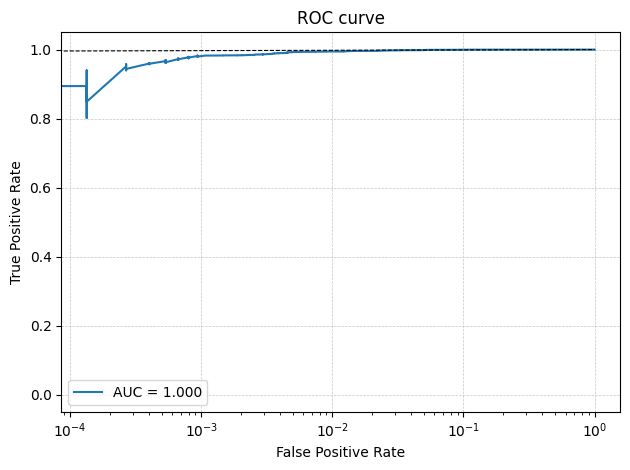

In [17]:
from building_tensorflow.utils import evaluate_binary_classifier, display_eval_metrics
train_metrics, test_metrics = evaluate_binary_classifier(training_model,
 train_ds,
 test_ds,
  threshold=0.5,)
display_eval_metrics(train_metrics, test_metrics)

## Make frontend filters into a Conv1D inference model


In [ ]:
# 1. Grab the SincNet frontend and execute the bake
frontend_layer = training_model.get_layer("sincnet_convolution")
baked_conv_layer = frontend_layer.export_to_conv1d(name="baked_sinc_conv")

# 2. Build the exact matching Inference Model
infer_inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))

x = baked_conv_layer(infer_inputs) 
x = tf.keras.layers.ReLU()(x) 
x = tf.keras.layers.GlobalAveragePooling1D()(x)

infer_hidden = tf.keras.layers.Dense(DENSE_HIDDEN, activation="relu", name="dense_hidden")(x)
infer_outputs = tf.keras.layers.Dense(num_labels, activation=None, name="dense_logits")(infer_hidden)

inference_model = tf.keras.Model(infer_inputs, infer_outputs, name="sincnet_inference")

# 3. Copy standard weights
inference_model.get_layer("dense_hidden").set_weights(
    training_model.get_layer("dense_hidden").get_weights()
)
inference_model.get_layer("dense_logits").set_weights(
    training_model.get_layer("dense_logits").get_weights()
)

# 4. Run the parity check
for batch_audio, _ in test_ds.take(1):
    batch_audio_np = batch_audio.numpy()
    
    logits_train = training_model.predict(batch_audio_np, verbose=0)
    logits_infer = inference_model.predict(batch_audio_np, verbose=0)
    
    max_diff = np.max(np.abs(logits_train - logits_infer))
    print(f"Max abs diff between SincNet training and INT8-ready inference: {max_diff:.8f}")

ValueError: No such layer: sincnet_frontend. Existing layers are: ['input_layer_2', 'sincnet_convolution', 're_lu_4', 'envelope_pool', 'temporal_conv_1', 're_lu_5', 'temporal_pool_1', 'temporal_conv_2', 're_lu_6', 'global_average_pooling1d_2', 'dense_hidden', 'dense_logits'].

## Export quantized TFLite model and Rust audio samples

We now export an int8-quantized TFLite model using the shared helpers from `building_tensorflow.utils`, and regenerate `audio_sample.rs` clips for the TinyChirp Rust runner.

In [ ]:
rep_batches = build_representative_batches(
    test_ds,
    target_len=TARGET_AUDIO_LEN_TIME,
    take=100,
)

try:
    export_keras_model_to_int8_tflite(inference_model, rep_batches, OUT_TFLITE)
    print(f"Success! Wrote {OUT_TFLITE}")
except Exception as e:
    print(f"TFLite conversion failed: {e}")

In [ ]:
from building_tensorflow.utils import evaluate_tflite_model

train_m, test_m, avg_ms = evaluate_tflite_model(OUT_TFLITE, "sincnet_time_tf", train_ds, test_ds)
print(f"Avg inference: {avg_ms:.3f} ms")